# Class 4: Changing dataframe shape

&nbsp;  
In this class, we'll be looking at three additional tools for tidying your data - **transposing**, **melting** and **casting**. Transposing rotates the data so that rows become columns and vice versa. Melting converts a dataframe from wide to long format, and casting is the reverse. You'll be able to practice these techniques using a couple of different datasets.

## Load the modules

First, let's import pandas and seaborn.

In [1]:
import pandas as pd
import seaborn as sns

## Transposing

&nbsp;  
<div>
<img src="attachment:dna-163466_640.jpg" width='50%' title=""/>
</div>
&nbsp;  

Start by loading in Infection_TPM.csv from the Datasets folder. This dataset includes transcripts per million (a measure of gene expression) of 7 genes. Call it df.

In [2]:
df_input = pd.read_csv('../Datasets/Infection_TPM.csv')

Now look at the top 5 rows of the dataset.

In [3]:
df_input.head()

,Gene_ID,Control_Flower,Infected_Flower,Control_leaf,Infected_leaf
0,NLR_1,34,45,20,23
1,NLR_2,1,33,3,56
2,JA_34,3,321,15,543
3,JA_13,5,45,3,22
4,JA_5,21,34,31,67


To transpose the data, you can simply use `df = df_input.T`. Type this into the cell below and then check the dataset to see what it looks like.

*Note: we updated the answers to give the transposed data frame a different name from the original. This avoids problems if you run code like `df = df.T` twice ... not a good idea. *

In [4]:
df = df_input.T
df.head()

,0,1,2,3,4,5,6
Gene_ID,NLR_1,NLR_2,JA_34,JA_13,JA_5,Aux_3,Aux_4
Control_Flower,34,1,3,5,21,4,6
Infected_Flower,45,33,321,45,34,72,23
Control_leaf,20,3,15,3,31,7,2
Infected_leaf,23,56,543,22,67,21,19


You can see that our columns have become rows and our rows have become columns. The index is now the column headers and the column headers are now the index. For this dataset, it would make sense to make the first row the column headers. So let's define our new column headers and then drop the first row.

In [5]:
col_names = ['NLR_1', 'NLR_2', 'JA_34', 'JA_13', 'JA_5', 'Aux_3', 'Aux_4']
df.columns = col_names
df = df.drop('Gene_ID')
df

,NLR_1,NLR_2,JA_34,JA_13,JA_5,Aux_3,Aux_4
Control_Flower,34,1,3,5,21,4,6
Infected_Flower,45,33,321,45,34,72,23
Control_leaf,20,3,15,3,31,7,2
Infected_leaf,23,56,543,22,67,21,19


In [6]:
# another way to get those col_names would be to extract them as a list
col_names = df_input['Gene_ID'].to_list()
col_names

['NLR_1', 'NLR_2', 'JA_34', 'JA_13', 'JA_5', 'Aux_3', 'Aux_4']

What happens if we want to analyse the differences between 'infected' and 'control' plants? Ideally, we would make two new columns - one for tissue (flower / leaf) and one for disease (infected / control). You may remember we did something similar in the last class by splitting strings. This time, however, it is the **index** that combines both pieces of information.

Let's first make the index a column. We can do this using the `df.reset_index()` function. 

Check the help page for `reset_index` to understand what it does, and what the argument `inplace = True` means, before you run the code? Help page:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html

In [7]:
df.reset_index(inplace = True)

*Warning: if you run this code:*
    
`df = df.reset_index(inplace = True)`,

*you will overwrite the dataframe `df` and have to create it again. This could be part of the learning process.*

Alternatively, you could run this code

`df = df.reset_index(inplace = False)`

In [8]:
df

,index,NLR_1,NLR_2,JA_34,JA_13,JA_5,Aux_3,Aux_4
0,Control_Flower,34,1,3,5,21,4,6
1,Infected_Flower,45,33,321,45,34,72,23
2,Control_leaf,20,3,15,3,31,7,2
3,Infected_leaf,23,56,543,22,67,21,19


This function creates a new column called 'index'. (Note: you can add `drop = True` into the df.reset_index function and the new 'index' column will be dropped). We can now split this 'index' column to make two new columns.

Let's call those columns Disease and Tissue. Check you understand every part of this line of code.

In [9]:
# Leave this code in for student notebook
df[['Disease', 'Tissue']] = df['index'].str.split('_', expand = True)

In [10]:
df

,index,NLR_1,NLR_2,JA_34,JA_13,JA_5,Aux_3,Aux_4,Disease,Tissue
0,Control_Flower,34,1,3,5,21,4,6,Control,Flower
1,Infected_Flower,45,33,321,45,34,72,23,Infected,Flower
2,Control_leaf,20,3,15,3,31,7,2,Control,leaf
3,Infected_leaf,23,56,543,22,67,21,19,Infected,leaf


Write some code to drop the 'index' column as we dont need it anymore. Then check to see everything has worked as expected.

In [11]:
df = df.drop(columns = 'index')
df

,NLR_1,NLR_2,JA_34,JA_13,JA_5,Aux_3,Aux_4,Disease,Tissue
0,34,1,3,5,21,4,6,Control,Flower
1,45,33,321,45,34,72,23,Infected,Flower
2,20,3,15,3,31,7,2,Control,leaf
3,23,56,543,22,67,21,19,Infected,leaf


Now that we have separated 'Disease' and 'Tissue', we can analyse these variables separately. For example, we might want to look at the differences in gene expression between Tissues:

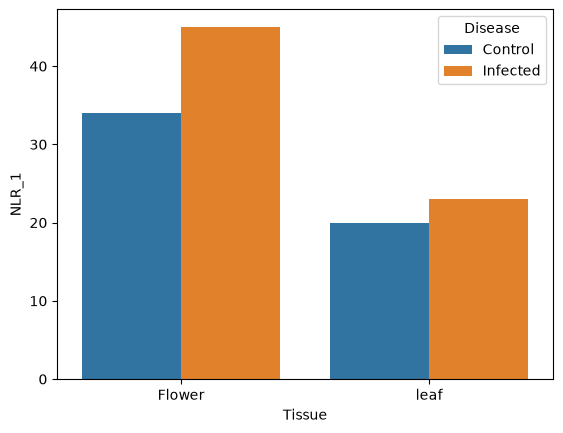

In [12]:
sns.barplot(x = 'Tissue', y = 'NLR_1', hue = 'Disease', data = df);

## Melting

How could we tidy these data further? At the moment, all of our TPM values are distributed over the first 6 columns. However, it is often useful to have all our measured values in a single column. We call this converting from 'wide form' to 'long form'. For our dataset, this would mean we would end up with four columns: Gene_ID, Disease, Tissue and TPM.

To do this, we can use the function `pd.melt`. This takes the form `pd.melt(dataframe, id_vars, value_vars, var_name, value_name...)`.

- `id_vars` are the identifier variables. These are the variables (or columns) that do not contain our values. In our case, these are Disease and Tissue.
- `value_vars` are the variables (or columns) that contain our values. In our case, these are NLR_1, NLR_2, JA_34, JA_13, JA_5, Aux_3 and Aux_4.
- `var_name` is the name we want to assign to our variable column. In this case, we shall call it 'Gene_ID'.
- `value_name` is the name we want to assign to our column of values. In this case, we shall call in 'TPM'.

Let's try it...

In [13]:
df_melt = pd.melt (df, id_vars = ['Disease', 'Tissue'], 
                   value_vars = ['NLR_1', 'NLR_2', 'JA_34', 'JA_13', 'JA_5', 'Aux_3', 'Aux_4'],
                   var_name = 'Gene_ID', value_name = 'TPM')

In [14]:
df_melt.head()

,Disease,Tissue,Gene_ID,TPM
0,Control,Flower,NLR_1,34
1,Infected,Flower,NLR_1,45
2,Control,leaf,NLR_1,20
3,Infected,leaf,NLR_1,23
4,Control,Flower,NLR_2,1


Having data in long form like this makes it easier to perform various analyses. For example, we can now plot a similar graph to the one above but incorporating data from all the genes this time.

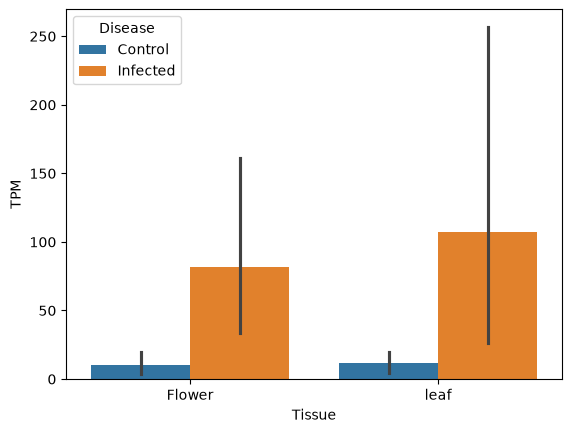

In [15]:
sns.barplot(x = 'Tissue', y = 'TPM', hue = 'Disease', data = df_melt);

This 'tidy data' form makes it easy to summarise by groups.  How would you get the mean and standard deviation of the gene expression levels by tissue?  By disease state?

We can break down the data further by gene...

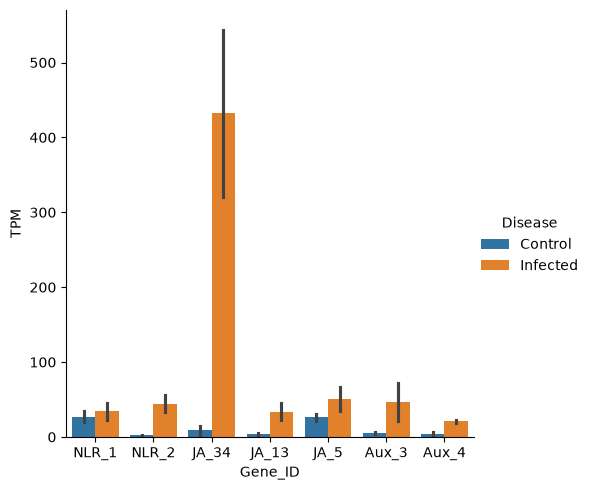

In [16]:
sns.catplot(x = 'Gene_ID', y = 'TPM', hue = 'Disease', data = df_melt, kind = 'bar');

Or we can look at the different 'tissues' separately...

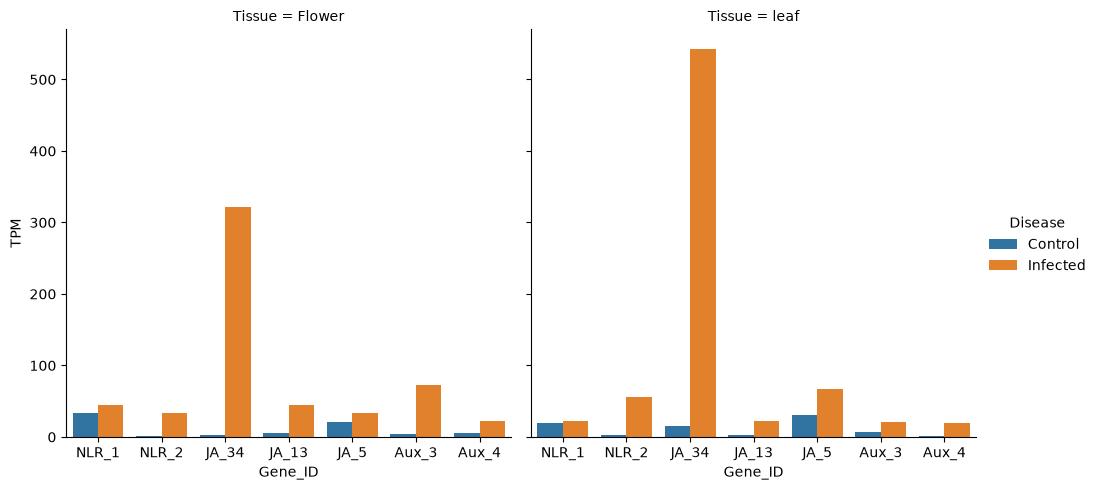

In [17]:
sns.catplot(x = 'Gene_ID', y = 'TPM', hue = 'Disease', data = df_melt, col = 'Tissue', kind = 'bar');

All this is easier because we have the dataframe arranged in a 'tidy' manner.

## Casting

Casting is the reverse of melting i.e. it converts long form data into wide form. We can do this using the `pd.pivot` function. This takes the form `pd.pivot(dataframe, columns, index, values...)`.

- `columns` is the column that we want to use to make the new dataframe's columns. In this case, it is Gene_ID.
- `index` is the column(s) that we want to use to make the new dataframe’s index. Let's do this with 'Tissue' and 'Disease'.
- `values` is the column containing our values. In this case, it is TPM.

In [18]:
df_cast = pd.pivot(df_melt, columns = 'Gene_ID', index = ['Tissue', 'Disease'], values = 'TPM')
df_cast

Gene_ID         Aux_3 Aux_4 JA_13 JA_34 JA_5 NLR_1 NLR_2
Tissue Disease                                          
Flower Control      4     6     5     3   21    34     1
       Infected    72    23    45   321   34    45    33
leaf   Control      7     2     3    15   31    20     3
       Infected    21    19    22   543   67    23    56

You might have noticed that we now have a multi-level index. We can reset 'Tissue' and 'Disease' to columns using `reset_index(inplace = True)`.
This makes the dataframe easier to read - which presumbly is why we wanted this wide-form data - as a table.

In [19]:
df_cast.reset_index(inplace = True)
df_cast

Gene_ID,Tissue,Disease,Aux_3,Aux_4,JA_13,JA_34,JA_5,NLR_1,NLR_2
0,Flower,Control,4,6,5,3,21,34,1
1,Flower,Infected,72,23,45,321,34,45,33
2,leaf,Control,7,2,3,15,31,20,3
3,leaf,Infected,21,19,22,543,67,23,56


### More practice with tidy data

Read in the Leaves.csv file in the Datasets folder and check things look OK.

In [20]:
df_leaves = pd.read_csv('../Datasets/Leaves.csv')

In [21]:
df_leaves.head()

,Plant,Genotype,ADH1,SSC2,SSC3,1,2,3,4,5,6,7,8,9,10,Side
0,MK_560_1,ddm1/ddm1,432.0,12.0,67.0,7,4,4,10,9,7,6,4,5,8,Adaxial
1,NaN,NaN,NaN,NaN,NaN,1,7,6,6,4,8,4,0,0,4,Abaxial
2,MK_560_2,ddm1/+,223.0,43.0,14.0,4,7,3,7,6,8,3,4,5,5,Adaxial
3,NaN,NaN,NaN,NaN,NaN,1,9,4,6,2,3,6,4,0,8,Abaxial
4,MK_560_3,wt,432.0,12.0,67.0,9,6,3,3,6,8,1,6,1,1,Adaxial


This dataset includes counts of hairs on the abaxial (underside) and adaxial (upperside) of ten leaves per plant (columns '1', '2' '3' ...), along with the expression levels for three genes (an average from three biological replicates) (ADH1, SSC2 and SSC3) and the genotype of each plant.

You can see that the data are in a horrible format! There are really 20 hair counts per plant (10 adaxial and 10 abaxial) but these have been split across 2 rows. This has generated a large number of NaNs.

Let's deal with this first. Pandas has functions called `df.fillna` and `df.ffill`, that allow filling these NaNs with something more meaningful. Try reading the pandas help page for those functions to understand what they do.

In our case, it makes sense to simply copy the information from the row above. We can do this using `df_leaves.ffill(inplace = True)`. Type this in to the cell below and have another look at your dataframe to see what it has done.

*Note: In previous versions of pandas the names of the functions were different. Previously, `ffill` was a method that could be accessed by `fillna`, by running the code `df.fillna(method = 'ffill', inplace = True)`. However, in pandas 3 versions, `ffill` is a separate function. We unfortunately only realized this live in class in October 2026 by troubleshooting code and reading the help pages.*

In [22]:
df_leaves.ffill(inplace = True)
df_leaves.head()

,Plant,Genotype,ADH1,SSC2,SSC3,1,2,3,4,5,6,7,8,9,10,Side
0,MK_560_1,ddm1/ddm1,432.0,12.0,67.0,7,4,4,10,9,7,6,4,5,8,Adaxial
1,MK_560_1,ddm1/ddm1,432.0,12.0,67.0,1,7,6,6,4,8,4,0,0,4,Abaxial
2,MK_560_2,ddm1/+,223.0,43.0,14.0,4,7,3,7,6,8,3,4,5,5,Adaxial
3,MK_560_2,ddm1/+,223.0,43.0,14.0,1,9,4,6,2,3,6,4,0,8,Abaxial
4,MK_560_3,wt,432.0,12.0,67.0,9,6,3,3,6,8,1,6,1,1,Adaxial


Now have a go melting your dataset into long form. Our identifier variables will be 'Plant', 'Genotype', 'ADH1', 'SSC2', 'SSC3' and 'Side'. Our values (or observations) are contained in the columns '1', '2' and '3'. Call your variable name 'Sample' and your value name 'Count'.

In [23]:
df_leaves_melt = pd.melt(df_leaves, id_vars = ['Plant', 'Genotype', 'ADH1', 'SSC2', 'SSC3', 'Side'],
                  value_vars = ['1', '2', '3'], var_name = 'Sample', value_name = 'Count')
df_leaves_melt

,Plant,Genotype,ADH1,SSC2,SSC3,Side,Sample,Count
0,MK_560_1,ddm1/ddm1,432.0,12.0,67.0,Adaxial,1,7
1,MK_560_1,ddm1/ddm1,432.0,12.0,67.0,Abaxial,1,1
2,MK_560_2,ddm1/+,223.0,43.0,14.0,Adaxial,1,4
3,MK_560_2,ddm1/+,223.0,43.0,14.0,Abaxial,1,1
4,MK_560_3,wt,432.0,12.0,67.0,Adaxial,1,9
5,MK_560_3,wt,432.0,12.0,67.0,Abaxial,1,2
6,MK_560_4,ddm1/+,189.0,37.0,10.0,Adaxial,1,9
7,MK_560_4,ddm1/+,189.0,37.0,10.0,Abaxial,1,1
8,MK_560_5,ddm1/ddm1,543.0,8.0,53.0,Adaxial,1,10
9,MK_560_5,ddm1/ddm1,543.0,8.0,53.0,Abaxial,1,1


What is the mean and sd for hair count on the adaxial and abaxial sides of the leaf?

In [24]:
df_leaves_melt.groupby(['Side']).agg({'Count':['mean','std']})

Count          
             mean       std
Side                       
Abaxial  3.888889  3.269986
Adaxial  5.555556  2.548869

What is the mean and sd for hair count on ddm1/ddm1, ddm/+ and +/+ leaves?

In [25]:
df_leaves_melt.groupby(['Genotype']).agg({'Count':['mean','std']})

Count          
               mean       std
Genotype                     
ddm1/+     4.277778  3.005985
ddm1/ddm1  5.333333  3.312053
wt         4.833333  2.639444

And grouping by Side and Genotype?

In [26]:
df_leaves_melt.groupby(['Side', 'Genotype']).agg({'Count':['mean','std']})

Count          
                       mean       std
Side    Genotype                     
Abaxial ddm1/+     3.111111  3.551213
        ddm1/ddm1  5.166667  3.371449
        wt         3.666667  2.081666
Adaxial ddm1/+     5.444444  1.878238
        ddm1/ddm1  5.500000  3.563706
        wt         6.000000  3.000000

What is the mean hair count by side for plants with ADH1 expression over 200?  Use df_melt.query("ADH1 > 200").groupby()

In [27]:
df_leaves_melt.query("ADH1 > 200").groupby(["position"])["points"].mean().reset_index()

KeyError: 'position'

And finally, use the following code to show the difference in hair counts between the adaxial and abaxial sides of the leaf for the different genotypes: `sns.catplot(x = 'Genotype', y = 'Count', hue = 'Side', data = df_leaves_melt, kind = 'bar');`.

In [ ]:
sns.catplot(x = 'Genotype', y = 'Count', hue = 'Side', data = df_leaves_melt, kind = 'bar');

## What to do next 

Class 4 homework gives more practise on re-shaping data, and on the material from previous classes.

You can also spend some time this week going over all the material we have covered so far. Are there any functions that you don't understand? Have a go playing with these on some other datasets. And if you haven't already, start putting together your own cheat sheet of useful functions.

## What to do next 

Class 4 homework gives more practise on re-shaping data, and on the material from previous classes.

You can also spend some time this week going over all the material we have covered so far. Are there any functions that you don't understand? Have a go playing with these on some other datasets. And if you haven't already, start putting together your own cheat sheet of useful functions.